# 📊 Notebook 1: Exploratory Data Analysis (EDA)

---

## What is EDA?
Exploratory Data Analysis (EDA) is the process of **visually and statistically summarizing** a dataset to understand its structure, detect patterns, spot anomalies, and test assumptions before applying any machine learning model.

## Why EDA?
- Understand what data you have
- Detect missing values, outliers, and duplicates
- Understand feature distributions
- Find relationships between features
- Make informed decisions about preprocessing

## Dataset Used
We use the **Titanic dataset** — a classic ML dataset containing information about passengers aboard the Titanic, and whether they survived.

| Feature | Description |
|---|---|
| `Survived` | Target variable: 0 = No, 1 = Yes |
| `Pclass` | Passenger class (1, 2, 3) |
| `Sex` | Gender |
| `Age` | Age in years |
| `SibSp` | # of siblings/spouses aboard |
| `Parch` | # of parents/children aboard |
| `Fare` | Ticket fare |
| `Embarked` | Port of embarkation (C/Q/S) |

---

## Step 1: Import Libraries

We need the following libraries:
- **`pandas`** — data manipulation and analysis
- **`numpy`** — numerical computing
- **`matplotlib`** — basic plotting
- **`seaborn`** — statistical data visualization built on top of matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places
sns.set_theme(style='whitegrid', palette='muted')  # Clean plot style
%matplotlib inline

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## Step 2: Load the Dataset

We load the Titanic dataset directly from an online URL using:
- **`pd.read_csv(url)`** — reads a CSV file into a DataFrame

> 💡 **Pandas Tip:** `pd.read_csv()` accepts file paths, URLs, or file-like objects.

In [4]:
# Load the Titanic dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print(f'Dataset loaded! Shape: {df.shape[0]} rows x {df.shape[1]} columns')

Dataset loaded! Shape: 891 rows x 12 columns


---
## Step 3: Initial Data Inspection

Before anything else, take a quick look at what the data contains.

### Key Pandas Methods:
| Method | Description |
|---|---|
| `df.head(n)` | First `n` rows (default 5) |
| `df.tail(n)` | Last `n` rows |
| `df.shape` | (rows, columns) tuple |
| `df.columns` | Column names |
| `df.dtypes` | Data type of each column |

In [27]:
# View the first 5 rows
print('=== First 5 Rows ===')
df.head()
#print(df.head(10))
#df.columns
#df.dtypes

=== First 5 Rows ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,NaN,S


In [22]:
# Check shape and column names
print(f'Shape: {df.shape}')  # (rows, columns)
print(f'\nColumns: {list(df.columns)}')

Shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [5]:
# Check data types of each column
# 'object' = text/categorical, 'int64'/'float64' = numeric
print('=== Data Types ===')
print(df.dtypes)

=== Data Types ===
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


---
## Step 4: Summary Statistics

Get a statistical overview of all numerical and categorical features.

### Key Pandas Methods:
| Method | Description |
|---|---|
| `df.describe()` | Count, mean, std, min, max for numeric cols |
| `df.describe(include='object')` | Summary for categorical (text) columns |
| `df.info()` | Data types + non-null counts per column |

In [6]:
# Statistical summary of numeric columns
print('=== Numeric Feature Summary ===')
df.describe()

=== Numeric Feature Summary ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [7]:
# Summary of categorical columns
print('=== Categorical Feature Summary ===')
df.describe(include='object')

=== Categorical Feature Summary ===


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [8]:
# Concise summary: dtypes + non-null counts + memory usage
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


---
## Step 5: Missing Value Analysis

Missing values (NaN) can break model training. We must identify and handle them.

### Key Pandas Methods:
| Method | Description |
|---|---|
| `df.isnull()` | Boolean DataFrame — True where value is NaN |
| `df.isnull().sum()` | Count of missing values per column |
| `df.isnull().mean() * 100` | Percentage missing per column |

In [36]:
# Count of missing values per column
missing_count = df.isnull().sum()
missing_pct = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

# Show only columns with missing values
print('=== Columns with Missing Values ===')
print(missing_df[missing_df['Missing Count'] > 0])

=== Columns with Missing Values ===
          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22


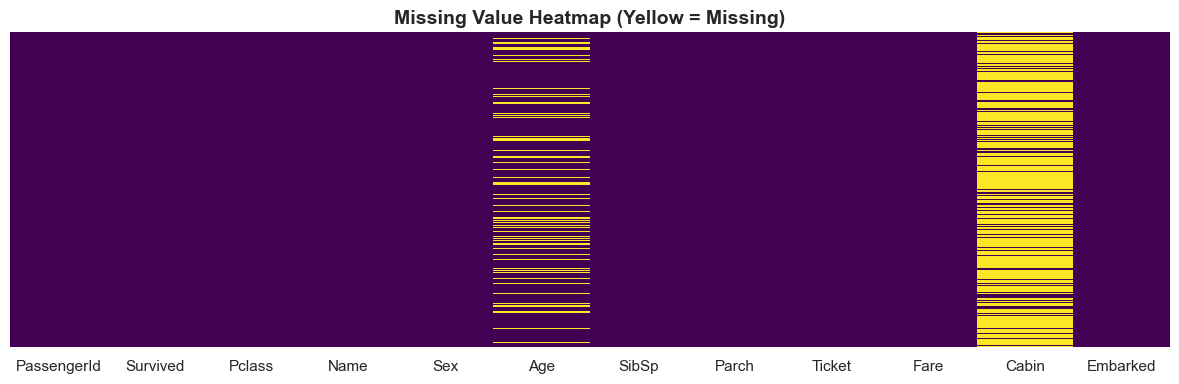

In [35]:
# Visualize missing values as a heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap (Yellow = Missing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 💡 Yellow streaks indicate missing values in that column

---
## Step 6: Univariate Analysis — Single Feature Exploration

Understand the **distribution** of individual features (one at a time).

### Key Pandas Methods:
| Method | Description |
|---|---|
| `df['col'].value_counts()` | Frequency of each unique value |
| `df['col'].value_counts(normalize=True)` | Relative frequency (proportions) |
| `df['col'].hist()` | Histogram of a numeric column |
| `df['col'].nunique()` | Number of unique values |

In [34]:
# Target variable distribution: Survived
print('=== Survival Count ===')
print(df['Survived'].value_counts())
print('\n=== Survival Rate ===')
print(df['Survived'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
#print(df['Survived'].unique())


=== Survival Count ===
Survived
0    549
1    342
Name: count, dtype: int64

=== Survival Rate ===
Survived
0    61.6%
1    38.4%
Name: proportion, dtype: str


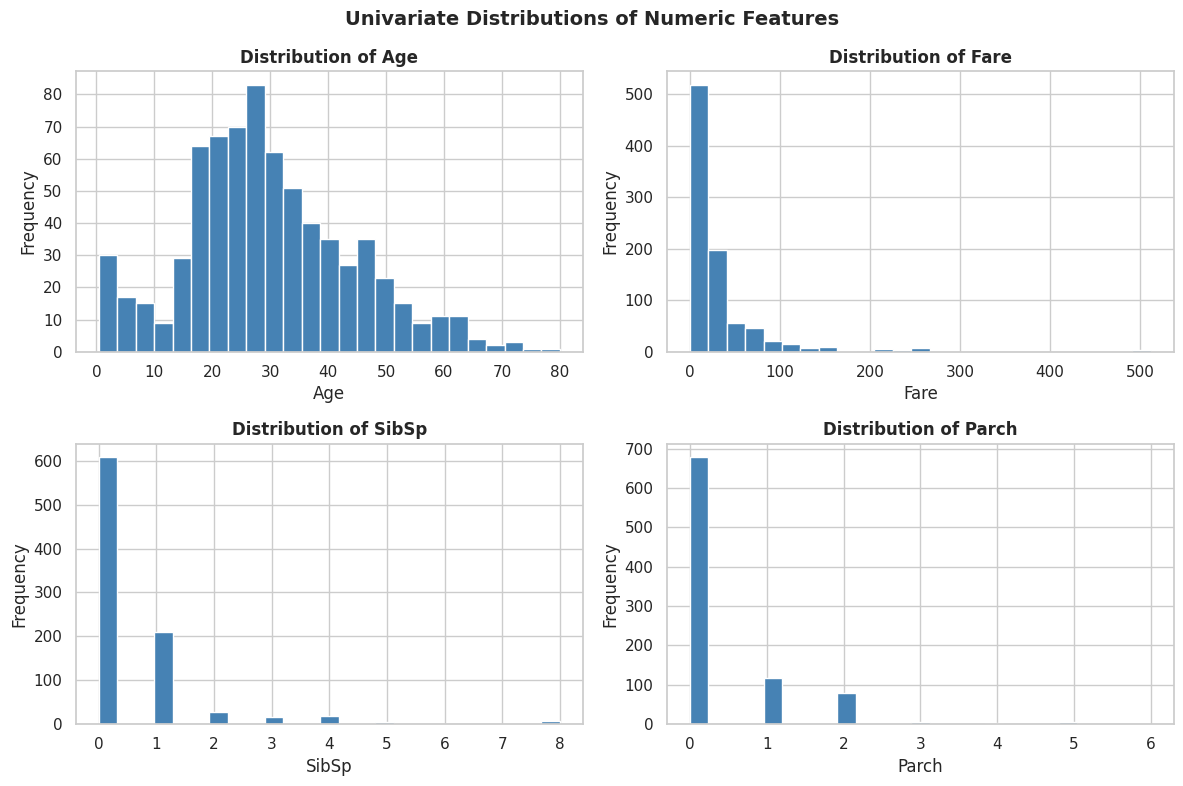

In [13]:
# Plot distributions for all numeric columns
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=25, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Univariate Distributions of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

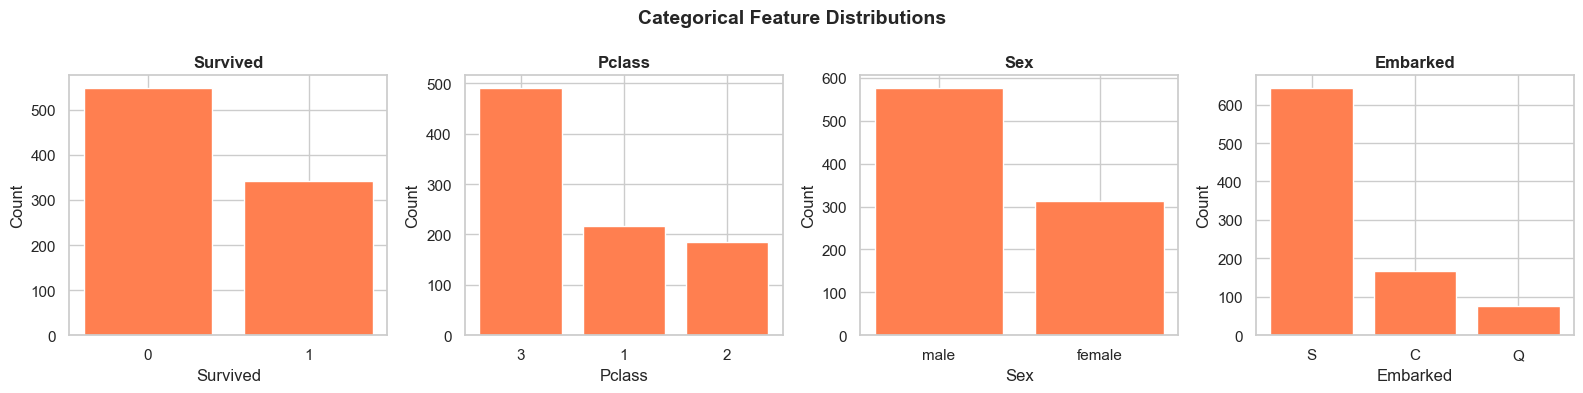

In [39]:
# Categorical column distributions
cat_cols = ['Survived', 'Pclass', 'Sex', 'Embarked']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color='coral', edgecolor='white')
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 7: Bivariate Analysis — Two Features Together

Understand **how features relate to each other** and to the target variable.

### Key Pandas Methods:
| Method | Description |
|---|---|
| `df.groupby('col')['target'].mean()` | Mean of target per group |
| `df.groupby('col').agg(...)` | Custom aggregation per group |
| `pd.crosstab(df['a'], df['b'])` | Frequency table of two categorical columns |

In [15]:
# Survival rate by Sex
print('=== Survival Rate by Sex ===')
print(df.groupby('Sex')['Survived'].mean().mul(100).round(1).astype(str) + '%')

# Survival rate by Passenger Class
print('\n=== Survival Rate by Pclass ===')
print(df.groupby('Pclass')['Survived'].mean().mul(100).round(1).astype(str) + '%')

=== Survival Rate by Sex ===
Sex
female    74.2%
male      18.9%
Name: Survived, dtype: object

=== Survival Rate by Pclass ===
Pclass
1    63.0%
2    47.3%
3    24.2%
Name: Survived, dtype: object


In [16]:
# Cross-tabulation: Sex vs Survived
print('=== Cross-tab: Sex vs Survived ===')
print(pd.crosstab(df['Sex'], df['Survived'], margins=True))

=== Cross-tab: Sex vs Survived ===
Survived    0    1  All
Sex                    
female     81  233  314
male      468  109  577
All       549  342  891


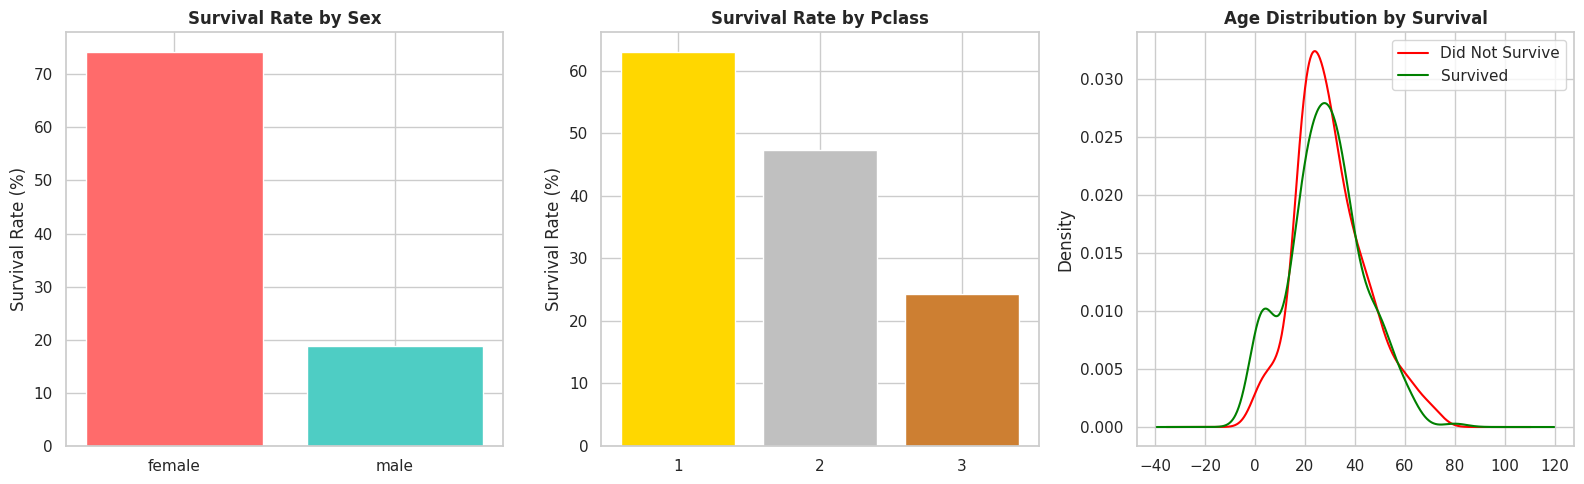

In [18]:
# Bivariate plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Survival rate by Sex
survival_sex = df.groupby('Sex')['Survived'].mean() * 100
axes[0].bar(survival_sex.index, survival_sex.values, color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Survival Rate by Sex', fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)')

# Plot 2: Survival rate by Pclass
survival_class = df.groupby('Pclass')['Survived'].mean() * 100
axes[1].bar(survival_class.index.astype(str), survival_class.values, color=['gold', 'silver', '#cd7f32'])
axes[1].set_title('Survival Rate by Pclass', fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')

# Plot 3: Age distribution by Survival (KDE)
df[df['Survived'] == 0]['Age'].dropna().plot(kind='kde', ax=axes[2], label='Did Not Survive', color='red')
df[df['Survived'] == 1]['Age'].dropna().plot(kind='kde', ax=axes[2], label='Survived', color='green')
axes[2].set_title('Age Distribution by Survival', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## Step 8: Correlation Analysis

Understand **linear relationships** between numeric features.

### Key Pandas Methods:
| Method | Description |
|---|---|
| `df.corr()` | Pearson correlation matrix (numeric cols) |
| `df.corr(method='spearman')` | Spearman rank correlation |

> 💡 **Interpretation:**
> - `1.0` = perfect positive correlation
> - `-1.0` = perfect negative correlation
> - `0.0` = no linear relationship

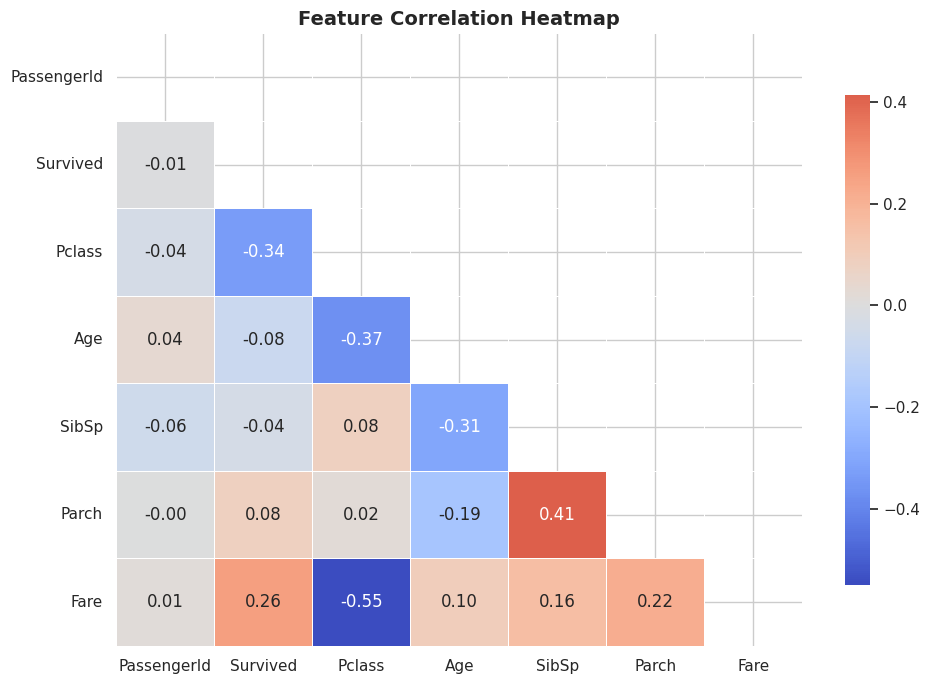

In [19]:
# Select numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

# Compute Pearson correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Show top correlations with the target 'Survived'
print('=== Correlation with Target (Survived) ===')
target_corr = corr_matrix['Survived'].drop('Survived').sort_values(key=abs, ascending=False)
print(target_corr.round(3))

=== Correlation with Target (Survived) ===
Pclass        -0.34
Fare           0.26
Parch          0.08
Age           -0.08
SibSp         -0.04
PassengerId   -0.01
Name: Survived, dtype: float64


---
## Step 9: Outlier Detection

Outliers are extreme values that may distort model training. We use **boxplots** and the **IQR method** to detect them.

### IQR Method:
- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 - Q1
- Outliers: values below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`

### Key Pandas Methods:
| Method | Description |
|---|---|
| `df['col'].quantile(0.25)` | 25th percentile |
| `df['col'].quantile(0.75)` | 75th percentile |

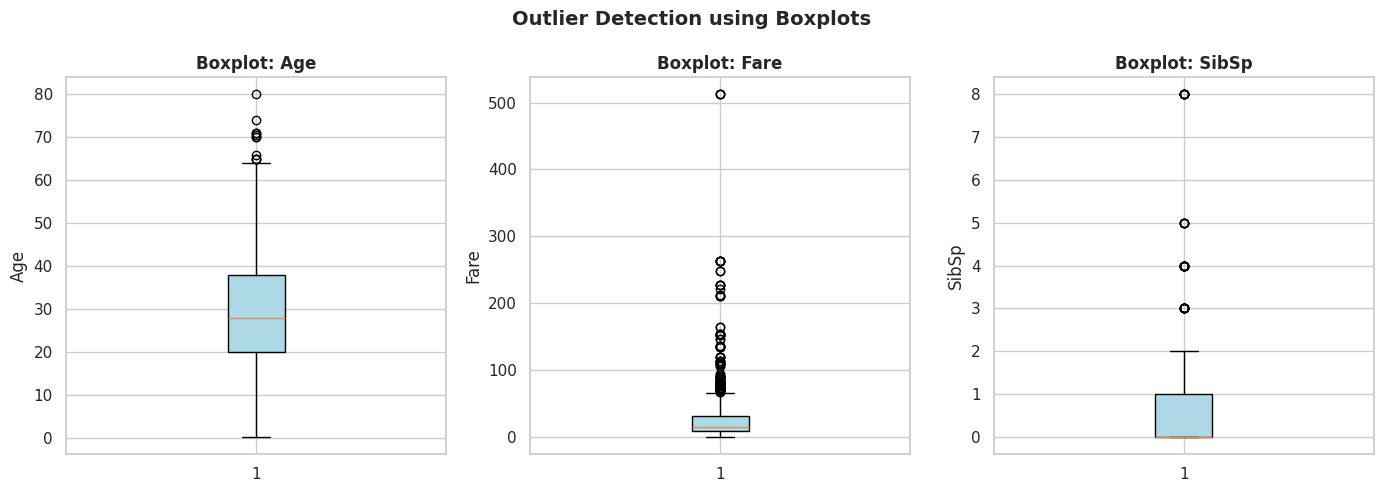

In [21]:
# Boxplots for numeric features
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(['Age', 'Fare', 'SibSp']):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Outlier Detection using Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Detect outliers using IQR method
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return len(outliers), lower, upper

print('=== Outlier Detection (IQR Method) ===')
for col in ['Age', 'Fare', 'SibSp', 'Parch']:
    n_outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f'{col:10s}: {n_outliers} outliers  [bounds: {lower:.1f}, {upper:.1f}]')  

=== Outlier Detection (IQR Method) ===
Age       : 11 outliers  [bounds: -6.7, 64.8]
Fare      : 116 outliers  [bounds: -26.7, 65.6]
SibSp     : 46 outliers  [bounds: -1.5, 2.5]
Parch     : 213 outliers  [bounds: 0.0, 0.0]


---
## Step 10: EDA Summary & Key Findings

Summarize what we learned.

In [23]:
print('=' * 55)
print('       📋 EDA SUMMARY: TITANIC DATASET')
print('=' * 55)
print(f"Total Rows      : {df.shape[0]}")
print(f"Total Features  : {df.shape[1]}")
print(f"Target Variable : Survived (Binary: 0/1)")
print(f"Survival Rate   : {df['Survived'].mean()*100:.1f}%")
print()
print('Missing Values:')
for col in df.columns:
    miss = df[col].isnull().sum()
    if miss > 0:
        print(f"  {col}: {miss} ({miss/len(df)*100:.1f}%)")
print()
print('Key Observations:')
print('  - Women had much higher survival rates than men')
print('  - 1st class passengers survived more than 3rd class')
print('  - Age: Children had slightly higher survival rates')
print('  - Fare is positively correlated with survival')
print('  - Age and Cabin have significant missing values')
print()
print('Next Steps → Notebook 2: Data Transformation & Encoding')

       📋 EDA SUMMARY: TITANIC DATASET
Total Rows      : 891
Total Features  : 12
Target Variable : Survived (Binary: 0/1)
Survival Rate   : 38.4%

Missing Values:
  Age: 177 (19.9%)
  Cabin: 687 (77.1%)
  Embarked: 2 (0.2%)

Key Observations:
  - Women had much higher survival rates than men
  - 1st class passengers survived more than 3rd class
  - Age: Children had slightly higher survival rates
  - Fare is positively correlated with survival
  - Age and Cabin have significant missing values

Next Steps → Notebook 2: Data Transformation & Encoding


---
## 📚 Quick Reference: Pandas Methods Used in this Notebook

| Method | Purpose |
|---|---|
| `pd.read_csv()` | Load CSV data |
| `df.head()` / `df.tail()` | Preview data |
| `df.shape` | Dataset dimensions |
| `df.dtypes` | Column data types |
| `df.describe()` | Summary statistics |
| `df.info()` | Non-null counts + types |
| `df.isnull().sum()` | Missing value counts |
| `df['col'].value_counts()` | Frequency of categories |
| `df.groupby().mean()` | Group-level averages |
| `pd.crosstab()` | Cross-tabulation |
| `df.corr()` | Correlation matrix |
| `df['col'].quantile()` | Percentiles for IQR |
| `df.select_dtypes()` | Filter by dtype |